# Character-Level Text Generation with RNN
### Hands-On Deep Learning & NLP Session

---
**The core idea:** Train an RNN to predict the *next character* given all previous characters.
After training, seed it with a few characters and let it generate new text!

```
Input :  T  o     b  e     o  r     n  o  t
          ↓  ↓  ↓  ↓  ↓  ↓  ↓  ↓  ↓  ↓  ↓  ↓
Output:   o     b  e     o  r     n  o  t    
           (predict the NEXT character at every step)
```

**Dataset:** Shakespeare's works (Tiny Shakespeare — ~1MB of text)

---
### Notebook road-map
| Step | What happens |
|------|--------------|
| 1 | Imports & reproducibility seeds |
| 2 | Download & inspect raw text |
| 3 | Build character vocabulary (char ↔ integer) |
| 4 | Visualise character distribution |
| 5 | Sliding-window dataset & DataLoader |
| 6 | Define the CharRNN model |
| 7 | Temperature-based generation function |
| 8 | Train the model |
| 9 | Plot loss & perplexity curves |
| 10 | Watch text quality improve epoch by epoch |
| 11 | Explore temperature effects |
| 12 | Interactive generation sandbox |
| 13 | Probe what the model has learned |
| 14–15 | Compare RNN / GRU / LSTM |


---
## 1. Setup

**What this cell does:**  
- Imports every library used throughout the notebook.  
- Fixes random seeds in PyTorch, NumPy, and Python's `random` module so results are
  reproducible across runs.  
- Auto-selects GPU if one is available; falls back to CPU otherwise.

> **Note:** All subsequent cells depend on the variables defined here (`device`, `SEED`),
> so always run this cell first after opening the notebook.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import os, random, math

# ── Reproducibility ────────────────────────────────────────────────────────────
# Setting the same seed in all three libraries ensures that shuffling, weight
# initialisation, and dropout masks produce identical results on every run.
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# ── Device selection ──────────────────────────────────────────────────────────
# Training on GPU is ~10–50x faster than CPU for this model.
# torch.cuda.is_available() returns True only when a CUDA-capable GPU is present.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print(f'PyTorch: {torch.__version__}')

Device : cuda
PyTorch: 2.10.0+cu128


---
## 2. Load the Shakespeare Dataset

**What this cell does:**  
- Downloads the *Tiny Shakespeare* dataset (~1 MB) from Andrej Karpathy's char-rnn repo
  the first time the notebook is run; on subsequent runs it reads the cached local file.  
- Truncates the corpus to 200 000 characters so training finishes in a few minutes on CPU.

**Why Tiny Shakespeare?**  
It contains a rich mix of prose, verse, stage directions, and character names — the model
has to learn letter patterns, word boundaries, punctuation, and even formatting conventions
purely from raw characters.

> **Experiment:** Change `200_000` to `50_000` for a faster run, or remove the slice
> altogether to train on the full ~1 MB corpus.

In [2]:
DATA_PATH = 'shakespeare.txt'

# Download only if the file is not already cached locally.
if not os.path.exists(DATA_PATH):
    url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
    print('Downloading Tiny Shakespeare ...')
    urllib.request.urlretrieve(url, DATA_PATH)
    print('Done!')

with open(DATA_PATH, 'r') as f:
    text = f.read()

# Truncate to keep training time manageable during the session.
# 200 000 chars ≈ the first ~4 Shakespeare plays.
text = text[:200_000]

print(f'Total characters : {len(text):,}')
print(f'\nFirst 300 chars:\n{"-"*40}')
print(text[:300])

Done!
Total characters : 200,000

First 300 chars:
----------------------------------------
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


---
## 3. Build Character Vocabulary

**What this cell does:**  
- Collects every **unique character** in the corpus and sorts them to produce a stable ordering.  
- Builds two look-up dictionaries: `ch2idx` (char → integer) and `idx2ch` (integer → char).  
- Converts the entire text string into a 1-D `torch.LongTensor` of indices.

**Why integers, not raw characters?**  
Neural networks operate on numbers. Each integer will later be passed through an `nn.Embedding`
layer that maps it to a dense vector the RNN can process.

**Vocabulary size insight:**  
A character vocabulary is tiny (~65 tokens) compared to word-level vocabularies (50 000+).
This makes char-level models fast to train but slower to generate coherent long-range structure.

In [3]:
# sorted(set(...)) gives a deterministic, alphabetically-ordered set of unique chars.
chars  = sorted(set(text))
VOCAB  = len(chars)                               # total number of unique characters
ch2idx = {ch: i for i, ch in enumerate(chars)}   # character → integer index
idx2ch = {i: ch for ch, i in ch2idx.items()}      # integer index → character

print(f'Vocabulary size : {VOCAB}')
print(f'Characters      : {repr("".join(chars))}')

# Encode the full text as a 1-D tensor of integer indices.
# dtype=torch.long is required by nn.Embedding.
data = torch.tensor([ch2idx[c] for c in text], dtype=torch.long)
print(f'\nEncoded shape   : {data.shape}')
print(f'First 20 ids    : {data[:20].tolist()}')
print(f'Decoded back    : {repr("".join(idx2ch[i] for i in data[:20].tolist()))}')

Vocabulary size : 62
Characters      : "\n !&',-.:;?ABCDEFGHIJKLMNOPQRSTUVWYZabcdefghijklmnopqrstuvwxyz"

Encoded shape   : torch.Size([200000])
First 20 ids    : [16, 44, 53, 54, 55, 1, 13, 44, 55, 44, 61, 40, 49, 8, 0, 12, 40, 41, 50, 53]
Decoded back    : 'First Citizen:\nBefor'


---
## 4. Visualise the Data

**What this cell does:**  
Produces two diagnostic plots before any model is built:

1. **Character frequency bar chart** — shows which characters dominate the corpus.
   Space `' '` and `'e'` are typically the most common; rare characters like `'Z'`
   appear far less often. This affects how well the model learns each character.

2. **Index sequence plot** — visualises the raw encoded text as a time-series of
   integer values. Repeating bands correspond to recurring characters (spaces, newlines).

> **Observation:** If your corpus has very few distinct characters the model will learn
> faster but produce less varied output; a rich vocabulary slows learning.

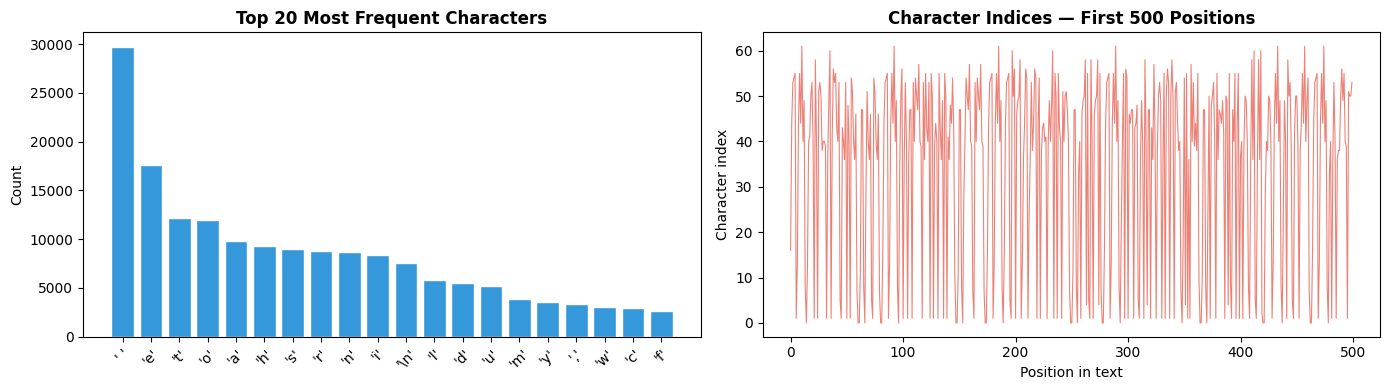

In [4]:
from collections import Counter

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Plot 1: character frequency ────────────────────────────────────────────────
# Counter.most_common(20) returns the 20 highest-frequency (char, count) pairs.
counts = Counter(text)
top20  = counts.most_common(20)
labels = [repr(c) for c, _ in top20]   # repr() makes whitespace chars readable, e.g. ' ' → "' '"
values = [n for _, n in top20]
axes[0].bar(labels, values, color='#3498DB', edgecolor='white')
axes[0].set_title('Top 20 Most Frequent Characters', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# ── Plot 2: encoded sequence (first 500 positions) ────────────────────────────
# Treats each character index as a scalar signal over time.
# Vertical jumps show character changes; flat regions are repeated characters.
axes[1].plot(data[:500].numpy(), alpha=0.7, linewidth=0.8, color='#E74C3C')
axes[1].set_title('Character Indices — First 500 Positions', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Position in text')
axes[1].set_ylabel('Character index')

plt.tight_layout()
plt.show()

---
## 5. Create Training Sequences

**What this cell does:**  
Defines how raw text is converted into `(input, target)` pairs the model can train on.

**Sliding window strategy:**  
We extract overlapping windows of `SEQ_LEN` characters. The target is the same window
shifted one position to the right — i.e. the character that comes *after* each input character.

```
Text  : H  e  l  l  o     W  o  r  l  d
Input : [H  e  l  l  o]  [e  l  l  o  _]  ...
Target: [e  l  l  o  _]  [l  l  o  _  W]  ...
```

**Why overlap?** The network sees every character in multiple contexts, which improves
generalisation compared to non-overlapping chunks.

> **Key hyperparameter:** `SEQ_LEN` controls how much context the model sees during one
> forward pass. Longer sequences capture more long-range dependencies but use more memory.

In [5]:
SEQ_LEN = 100   # number of characters per training sequence (context window length)


class ShakespeareDataset(Dataset):
    """PyTorch Dataset for character-level language modelling.

    Wraps a 1-D tensor of character indices and returns overlapping
    (input, target) sequence pairs using a sliding window of fixed length.
    The target is the input shifted one position to the right, so the model
    learns to predict the next character at every time step.

    Args:
        data    (torch.LongTensor): Encoded character sequence of shape (N,).
        seq_len (int)             : Length of each input/target window.

    Example:
        >>> ds = ShakespeareDataset(data, seq_len=100)
        >>> x, y = ds[0]          # x and y are both shape (100,)
        >>> # y[i] == x[i+1] for all i
    """

    def __init__(self, data: torch.Tensor, seq_len: int) -> None:
        """Store the full encoded corpus and the desired window size."""
        self.data    = data
        self.seq_len = seq_len

    def __len__(self) -> int:
        """Return number of valid (input, target) pairs.

        We lose the last `seq_len` positions because a full target window
        cannot be formed there.
        """
        return len(self.data) - self.seq_len

    def __getitem__(self, idx: int):
        """Return the input and target windows starting at position `idx`.

        Args:
            idx (int): Start position of the window.

        Returns:
            Tuple[torch.LongTensor, torch.LongTensor]:
                x — characters at positions [idx, idx+seq_len)
                y — characters at positions [idx+1, idx+seq_len+1)  (shifted by 1)
        """
        x = self.data[idx          : idx + self.seq_len]
        y = self.data[idx + 1      : idx + self.seq_len + 1]
        return x, y


# ── Instantiate dataset and DataLoader ────────────────────────────────────────
dataset    = ShakespeareDataset(data, SEQ_LEN)
# shuffle=True: present sequences in random order each epoch to reduce correlation.
# drop_last=True: discard the final partial batch so all batches have the same size.
dataloader = DataLoader(dataset, batch_size=128, shuffle=True, drop_last=True)

print(f'Total sequences : {len(dataset):,}')
print(f'Batches/epoch   : {len(dataloader)}')

# Inspect one batch to verify shapes
xb, yb = next(iter(dataloader))
print(f'\nBatch X : {xb.shape}  (batch_size, seq_len)')
print(f'Batch y : {yb.shape}  (batch_size, seq_len)')
print(f'\nSample input  : {repr("".join(idx2ch[i] for i in xb[0,:20].tolist()))}')
print(f'Sample target : {repr("".join(idx2ch[i] for i in yb[0,:20].tolist()))}')

Total sequences : 199,900
Batches/epoch   : 1561

Batch X : torch.Size([128, 100])  (batch_size, seq_len)
Batch y : torch.Size([128, 100])  (batch_size, seq_len)

Sample input  : 'cunning: you were us'
Sample target : 'unning: you were use'


---
## 6. The CharRNN Model

**What this cell does:**  
Defines the neural network architecture and runs a quick shape sanity-check.

**Architecture overview:**
```
Input indices  →  Embedding  →  LSTM (stacked)  →  Dropout  →  Linear  →  logits
(B, L)            (B, L, E)      (B, L, H)                      (B, L, V)
```

| Layer | Role |
|-------|------|
| `nn.Embedding` | Maps each integer index to a trainable dense vector of size `embed_dim`. Learns semantic character representations. |
| `nn.LSTM` (or RNN/GRU) | Processes the embedded sequence step-by-step; the hidden state carries context from left to right. |
| `nn.Dropout` | Randomly zeroes activations during training — regularises the model to prevent over-fitting. |
| `nn.Linear` | Projects the hidden state at every time step to a score for each character in the vocabulary. |

**Loss function:** `nn.CrossEntropyLoss` — combines a `LogSoftmax` and `NLLLoss`;
it expects raw logits (not probabilities) and integer class labels.

In [6]:
class CharRNN(nn.Module):
    """Character-level language model using a stacked recurrent network.

    At each time step the model takes one character index, embeds it, passes
    it through one or more RNN/LSTM/GRU layers, and projects the resulting
    hidden state to a distribution over the full character vocabulary.
    During generation the output distribution is sampled to produce the next
    character, which becomes the next input.

    Args:
        vocab_size  (int)  : Number of unique characters (size of input/output space).
        embed_dim   (int)  : Dimensionality of the character embedding vectors.
        hidden_dim  (int)  : Number of features in the RNN hidden state.
        num_layers  (int)  : Number of stacked RNN layers.
        dropout     (float): Dropout probability applied after embedding and after RNN.
                             Ignored between layers when num_layers == 1.
        rnn_type    (str)  : One of 'RNN', 'LSTM', or 'GRU'.

    Shape conventions (using B=batch, L=seq_len, E=embed_dim, H=hidden_dim, V=vocab_size):
        forward input  : (B, L)       — integer character indices
        forward output : (B, L, V)    — raw logits over vocabulary at every step
    """

    def __init__(
        self,
        vocab_size : int,
        embed_dim  : int,
        hidden_dim : int,
        num_layers : int,
        dropout    : float = 0.3,
        rnn_type   : str   = 'LSTM'
    ) -> None:
        super().__init__()
        self.rnn_type   = rnn_type
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Embedding: integer index → dense float vector.
        # The embedding matrix has shape (vocab_size, embed_dim) and is updated
        # by back-propagation just like any other weight matrix.
        self.embed = nn.Embedding(vocab_size, embed_dim)

        # Select the recurrent cell type via a simple lookup.
        # All three share the same interface for our usage pattern.
        rnn_cls = {'RNN': nn.RNN, 'LSTM': nn.LSTM, 'GRU': nn.GRU}[rnn_type]
        self.rnn = rnn_cls(
            input_size  = embed_dim,
            hidden_size = hidden_dim,
            num_layers  = num_layers,
            batch_first = True,    # expects input shape (B, L, E) instead of (L, B, E)
            dropout     = dropout if num_layers > 1 else 0.0  # inter-layer dropout only
        )

        self.drop = nn.Dropout(dropout)

        # Project hidden state → vocabulary logits at every time step.
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x: torch.Tensor, hidden=None):
        """Run one forward pass over a batch of character sequences.

        Args:
            x      (torch.LongTensor): Character indices of shape (B, L).
            hidden (optional)        : Initial hidden state.
                                       - For LSTM: tuple (h_0, c_0), each (num_layers, B, H).
                                       - For RNN/GRU: tensor (num_layers, B, H).
                                       Defaults to zeros when None.

        Returns:
            logits (torch.Tensor): Raw scores of shape (B, L, vocab_size).
                                   Pass through CrossEntropyLoss directly (no softmax needed).
            hidden               : Updated hidden state (same structure as input `hidden`).
        """
        # Step 1 — embed: (B, L) → (B, L, E); apply dropout for regularisation
        emb = self.drop(self.embed(x))

        # Step 2 — recurrent pass: (B, L, E) → (B, L, H)
        # `out` contains the hidden state at every time step;
        # `hidden` is the final hidden state (useful for continuing generation).
        out, hidden = self.rnn(emb, hidden)

        # Step 3 — project to vocabulary: (B, L, H) → (B, L, V)
        logits = self.fc(self.drop(out))
        return logits, hidden

    def init_hidden(self, batch_size: int, device: torch.device):
        """Create a zero-filled initial hidden state for a given batch size.

        LSTM requires both a hidden state `h` and a cell state `c`, so this
        method returns a tuple for LSTM and a single tensor for RNN/GRU.

        Args:
            batch_size (int)           : Number of sequences in the batch.
            device     (torch.device)  : Target device (CPU or CUDA).

        Returns:
            For LSTM : Tuple[Tensor, Tensor], each of shape (num_layers, B, H).
            For RNN/GRU: Tensor of shape (num_layers, B, H).
        """
        h = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device)
        if self.rnn_type == 'LSTM':
            return (h, h.clone())  # LSTM needs both hidden state h and cell state c
        return h


# ── Instantiate the model ──────────────────────────────────────────────────────
model = CharRNN(
    vocab_size = VOCAB,
    embed_dim  = 64,    # embedding dimension — how richly each char is represented
    hidden_dim = 256,   # LSTM hidden units — model's "memory" capacity
    num_layers = 2,     # stacked layers — deeper = more expressive, slower to train
    dropout    = 0.3,   # 30% of activations dropped during training
    rnn_type   = 'LSTM'
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'\nTotal parameters: {total_params:,}')

# ── Shape sanity check ────────────────────────────────────────────────────────
# Verify that the output shape matches (batch, seq_len, vocab) before training.
dummy  = torch.randint(0, VOCAB, (4, SEQ_LEN)).to(device)
out, _ = model(dummy)
print(f'Output shape    : {out.shape}  ← (batch=4, seq={SEQ_LEN}, vocab={VOCAB}) ✅')

CharRNN(
  (embed): Embedding(62, 64)
  (rnn): LSTM(64, 256, num_layers=2, batch_first=True, dropout=0.3)
  (drop): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=62, bias=True)
)

Total parameters: 875,966
Output shape    : torch.Size([4, 100, 62])  ← (batch=4, seq=100, vocab=62) ✅


---
## 7. Text Generation Function

**What this cell does:**  
Defines the `generate()` function used to sample text from the model at any point,
and demonstrates what an *untrained* model produces (expected: random noise).

**Two-phase generation:**
1. **Warm-up** — feed the entire seed string through the model to build up a meaningful
   hidden state that represents the context of the seed.
2. **Auto-regressive loop** — repeatedly sample one character, append it to the output,
   and feed it back as the next input.

**Temperature sampling:**  
$$P(c_i) = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$$

| Temperature `T` | Effect on distribution | Typical output |
|---|---|---|
| `T → 0` | Collapses to argmax (one-hot) | Repetitive, safe |
| `T = 1` | Model's raw distribution | Balanced |
| `T > 1` | Flatter, more uniform | Creative, chaotic |

> **Note:** `torch.multinomial` draws one sample according to `probs` — this is
> stochastic, so two calls with the same seed can produce different text.

In [7]:
def generate(
    model      : nn.Module,
    seed       : str,
    length     : int   = 400,
    temperature: float = 1.0
) -> str:
    """Generate new text autoregressively from a trained CharRNN model.

    The seed string is first used to warm up the model's hidden state so that
    generation continues coherently from the given context.  One new character
    is sampled at a time using temperature-scaled softmax sampling.

    Args:
        model       (nn.Module): Trained CharRNN instance.
        seed        (str)      : Prompt string to condition the generation on.
                                 Must contain only characters present in `ch2idx`.
        length      (int)      : Number of *new* characters to generate after the seed.
        temperature (float)    : Sampling temperature.
                                 Values < 1 make output more deterministic;
                                 values > 1 make it more random.

    Returns:
        str: The seed followed by `length` generated characters.

    Example:
        >>> text = generate(model, seed='ROMEO:\n', length=200, temperature=0.8)
        >>> print(text)
    """
    model.eval()
    with torch.no_grad():
        chars_out = list(seed)   # start output with the seed characters

        # Encode the seed into a (1, len(seed)) tensor of integer indices.
        # Unknown characters fall back to index 0 via dict.get default.
        input_ids = torch.tensor(
            [[ch2idx.get(c, 0) for c in seed]], dtype=torch.long
        ).to(device)

        # Initialise hidden state to zeros.
        hidden = model.init_hidden(1, device)

        # Warm-up pass: run the full seed through the model so the hidden state
        # captures the context. We discard the logits here.
        _, hidden = model(input_ids, hidden)

        # Autoregressive generation loop.
        # At each step: take last character → get logits → sample → append → repeat.
        next_input = input_ids[:, -1:]   # shape (1, 1) — last char of the seed
        for _ in range(length):
            logits, hidden = model(next_input, hidden)  # logits: (1, 1, V)

            # Apply temperature scaling before converting logits to probabilities.
            scaled_logits = logits[:, -1, :] / temperature
            probs = torch.softmax(scaled_logits, dim=-1)  # (1, V)

            # Sample one character index according to the probability distribution.
            # multinomial returns shape (1, 1) — no unsqueeze needed.
            next_input = torch.multinomial(probs, num_samples=1)  # (1, 1)

            chars_out.append(idx2ch[next_input.item()])

    return ''.join(chars_out)


# ── Baseline: untrained model output ──────────────────────────────────────────
# Before training, weights are random, so the model will produce gibberish.
# This is the baseline we compare against after training.
print('=== UNTRAINED MODEL OUTPUT (expected: random noise) ===')
print(generate(model, seed='JULIET:\n', length=200))

=== UNTRAINED MODEL OUTPUT (expected: random noise) ===
JULIET:
J ?EATqaePFR,EqV.!Hw,xbrpggaTdFqtFEn-as?WfnL-xxJbcFMpaGR.PCU;HMoTsyzlvEeOKzKVR&btujITsRvCWhRx:ZIKfrGdA-hMhVLyLTg&Ro'aJp'qPGEHl,mPsvKe'kskb'pWdzFJHjx-ocmQYHjsvJHwip?fVMAm.J EShmPkgHlzVz.QSezxQrGklfhyR?


---
## 8. Training

**What this cell does:**  
Runs the main training loop for `EPOCHS` epochs and records loss, perplexity, and
text samples at regular intervals.

**Key training decisions:**

| Choice | Value | Why |
|--------|-------|-----|
| Loss | `CrossEntropyLoss` | Standard for multi-class next-token prediction |
| Optimiser | `Adam` (lr=3e-3) | Adaptive learning rates; converges faster than plain SGD |
| LR schedule | `CosineAnnealingLR` | Smoothly decays LR to near-zero — avoids overshooting late in training |
| Gradient clipping | `max_norm=1.0` | Prevents exploding gradients; especially important for vanilla RNN |
| Sample snapshots | every 5 epochs | Lets us watch text quality improve visually in Section 10 |

**Teacher forcing:**  
During training we always feed the *true* previous character as input (not the model's
own prediction). This stabilises training but creates a small train/inference mismatch.

> **Expected runtime:** ~3–6 min on CPU for 20 epochs with 200 000 characters.

In [8]:
EPOCHS    = 20
LR        = 3e-3
SEED_TEXT = 'ROMEO:\n'   # fixed seed used for progress snapshots during training

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
# CosineAnnealingLR: LR follows a cosine curve from LR → ~0 over T_max epochs.
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

train_losses   = []   # average cross-entropy loss per epoch
sample_outputs = {}   # {epoch: generated_text} — used in Section 10

for epoch in range(1, EPOCHS + 1):
    model.train()   # activates dropout
    epoch_loss = 0.0

    for xb, yb in dataloader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()

        # Forward pass: logits shape = (B, L, V)
        logits, _ = model(xb)

        # CrossEntropyLoss expects (N, C) and (N,).
        # Flatten batch and time dimensions: (B*L, V) and (B*L,).
        loss = criterion(logits.reshape(-1, VOCAB), yb.reshape(-1))

        loss.backward()   # compute gradients

        # Gradient clipping: scale down gradients whose L2 norm exceeds 1.0.
        # Without this, RNN gradients can explode especially in early epochs.
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()      # update weights
        epoch_loss += loss.item()

    scheduler.step()   # adjust learning rate

    avg_loss   = epoch_loss / len(dataloader)
    perplexity = math.exp(avg_loss)   # e^loss; ~= how many chars the model is guessing between
    train_losses.append(avg_loss)

    print(f'Epoch {epoch:3d}/{EPOCHS}  loss={avg_loss:.4f}  perplexity={perplexity:.1f}')

    # Capture a text snapshot at epoch 1 and every 5 epochs for later comparison.
    if epoch % 5 == 0 or epoch == 1:
        sample = generate(model, SEED_TEXT, length=150, temperature=0.8)
        sample_outputs[epoch] = sample
        print(f'  Sample → {repr(sample[:80])}\n')

print('\nTraining complete!')

Epoch   1/20  loss=1.4862  perplexity=4.4
  Sample → 'ROMEO:\nVALERIA:\nHe had deserved like a lover of him: but\nyou are done.\n\nCORIOLAN'

Epoch   2/20  loss=1.1672  perplexity=3.2
Epoch   3/20  loss=1.0783  perplexity=2.9
Epoch   4/20  loss=1.0223  perplexity=2.8
Epoch   5/20  loss=0.9803  perplexity=2.7
  Sample → "ROMEO:\nA Patrician:\nYet, as I lie to like enter'd to my love.\n\nMARCIUS:\nFool, wo"

Epoch   6/20  loss=0.9462  perplexity=2.6
Epoch   7/20  loss=0.9165  perplexity=2.5
Epoch   8/20  loss=0.8904  perplexity=2.4
Epoch   9/20  loss=0.8673  perplexity=2.4
Epoch  10/20  loss=0.8458  perplexity=2.3
  Sample → 'ROMEO:\nAUFIDIUS:\nOnly mother! Wouth, sir, well.\n\nMENENIUS:\nI will not keep your '

Epoch  11/20  loss=0.8273  perplexity=2.3
Epoch  12/20  loss=0.8093  perplexity=2.2
Epoch  13/20  loss=0.7940  perplexity=2.2
Epoch  14/20  loss=0.7806  perplexity=2.2
Epoch  15/20  loss=0.7691  perplexity=2.2
  Sample → "ROMEO:\nAUFIDIUS:\nThe consul Coriolanus.\n\nCORIOLANUS:\n

---
## 9. Training Curves

**What this cell does:**  
Plots the cross-entropy loss and perplexity across all training epochs.

**How to read these plots:**
- A **steadily decreasing loss** confirms the model is learning.
- A **flattening curve** indicates the model is approaching its capacity limit
  given the current architecture and data size.
- If loss decreases but generated text quality does not improve much, the model
  may be memorising rather than generalising (overfitting).

### What is Perplexity?
$$\text{Perplexity} = e^{\text{loss}} = e^{H(p,q)}$$

**Intuition:** how many characters is the model equally confused between?
| Perplexity | Meaning |
|------------|---------|
| ≈ vocab size (65) | Completely random — no learning |
| 5 – 10 | Model has strong context; narrows candidates significantly |
| 1 | Perfect prediction every time (impossible in practice) |

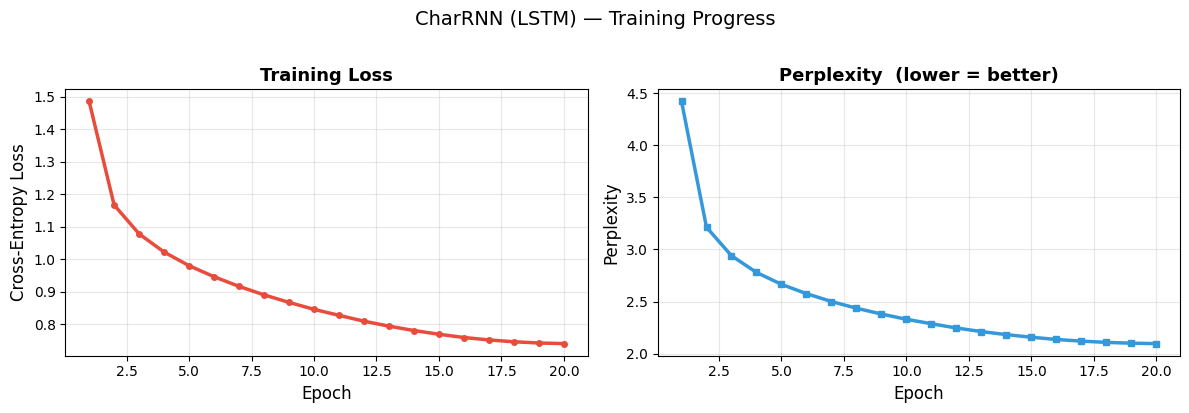

Start perplexity : 4.4
Final perplexity : 2.1
Improvement      : 2.1x


In [9]:
perplexities = [math.exp(l) for l in train_losses]
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Loss curve ────────────────────────────────────────────────────────────────
axes[0].plot(epochs_range, train_losses,
             color='#E74C3C', linewidth=2.5, marker='o', markersize=4)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Cross-Entropy Loss', fontsize=12)
axes[0].set_title('Training Loss', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)

# ── Perplexity curve ──────────────────────────────────────────────────────────
axes[1].plot(epochs_range, perplexities,
             color='#3498DB', linewidth=2.5, marker='s', markersize=4)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Perplexity', fontsize=12)
axes[1].set_title('Perplexity  (lower = better)', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.suptitle('CharRNN (LSTM) — Training Progress', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'Start perplexity : {perplexities[0]:.1f}')
print(f'Final perplexity : {perplexities[-1]:.1f}')
print(f'Improvement      : {perplexities[0]/perplexities[-1]:.1f}x')

---
## 10. Watch the Model Learn — Samples Across Epochs

**What this cell does:**  
Prints the text snapshots captured during training, ordered by epoch.
This is the most visually compelling part of a char-RNN demo.

**What to look for:**
| Epoch | Typical behaviour |
|-------|------------------|
| 1 | Random characters, no words |
| 5 | Short words appear; spacing begins to form |
| 10 | Valid English words; some punctuation patterns |
| 20 | Character names, dialogue format, rough syntax |

> The model has never been told what a "word" or "sentence" is — it discovers
> these structures purely by predicting the next character.

In [10]:
print('=' * 60)
print('  HOW GENERATED TEXT EVOLVES OVER TRAINING')
print('  Seed:', repr(SEED_TEXT))
print('=' * 60)

for epoch, text_sample in sorted(sample_outputs.items()):
    loss_at = train_losses[epoch - 1]
    perp_at = math.exp(loss_at)
    print(f'\n--- Epoch {epoch:3d}  loss={loss_at:.3f}  perplexity={perp_at:.1f} ---')
    print(text_sample[:250])
    print()

  HOW GENERATED TEXT EVOLVES OVER TRAINING
  Seed: 'ROMEO:\n'

--- Epoch   1  loss=1.486  perplexity=4.4 ---
ROMEO:
VALERIA:
He had deserved like a lover of him: but
you are done.

CORIOLANUS:
I will not jequest me
To make a greater valour hath not so
your own busin


--- Epoch   5  loss=0.980  perplexity=2.7 ---
ROMEO:
A Patrician:
Yet, as I lie to like enter'd to my love.

MARCIUS:
Fool, worthy Aufidius,
Thou hadst are here all the city gies,
Dire him to the costard


--- Epoch  10  loss=0.846  perplexity=2.3 ---
ROMEO:
AUFIDIUS:
Only mother! Wouth, sir, well.

MENENIUS:
I will not keep your honours so batted as thou wilt true.

Second Murderer:
I'll go with us, it ha


--- Epoch  15  loss=0.769  perplexity=2.2 ---
ROMEO:
AUFIDIUS:
The consul Coriolanus.

CORIOLANUS:
I' the sing o' the Capitol, what then?

VIRGILIA:
The voice of Rome are the helps
That in that struck ha


--- Epoch  20  loss=0.740  perplexity=2.1 ---
ROMEO:
SICINIUS:
First, the gods bless you spire for me,
And long s

---
## 11. Effect of Temperature on Generated Text

**What this cell does:**  
Runs the same trained model with the same seed at five different temperature values,
then visualises how temperature reshapes the probability distribution over the next character.

**Two outputs:**
1. **Text samples** — lets you qualitatively feel the temperature effect.
2. **Bar charts** — shows the *exact* probability mass shift for the top-15 candidate
   characters immediately after the string `'To be'`.

**Key insight:**  
Low temperature concentrates all probability mass on the top character, leading to
repetitive but grammatically safe output. High temperature spreads mass uniformly,
allowing rare characters to be sampled — useful for creativity, harmful for coherence.

In [11]:
SEED_TEXT    = 'JULIET:\n'
temperatures = [0.3, 0.7, 1.0, 1.3, 1.8]

# ── Text samples at each temperature ─────────────────────────────────────────
print(f'Seed: {repr(SEED_TEXT)}')
print('=' * 65)

temperature_labels = {
    0.3: '(very conservative — repetitive but safe)',
    0.7: '(conservative — coherent)',
    1.0: '(default — model\'s raw distribution)',
    1.3: '(creative — some unusual words)',
    1.8: '(chaotic — breaks down coherence)',
}

for T in temperatures:
    out = generate(model, SEED_TEXT, length=120, temperature=T)
    print(f'\nT={T}  {temperature_labels[T]}')
    print('-' * 40)
    print(out[len(SEED_TEXT):])   # print only the generated part, not the seed

Seed: 'JULIET:\n'

T=0.3  (very conservative — repetitive but safe)
----------------------------------------
SICINIUS:
He shall well know
The noble sister of Publicola,
The trumpets, sackbuts, perfirious thing that I am,
Though i

T=0.7  (conservative — coherent)
----------------------------------------
MARCIUS:
'Tis no matter.

CORIOLANUS:
To the Capitol?

BRUTUS:
Mark you that?

CORIOLANUS:
The cause of much prosonmes, 

T=1.0  (default — model's raw distribution)
----------------------------------------
First Senator:
She would account me the matter, you mistake my mind
A most inherers but
To see me again. You are all
Tha

T=1.3  (creative — some unusual words)
----------------------------------------
SICINIUS:
And thus dispatch
This body's man that end you.

First Senator:
Srephating have, defused mistress their countr

T=1.8  (chaotic — breaks down coherence)
----------------------------------------
Second Lord:
Yee, Mircaus!'

MENENIUS:
Yet, you compant? Here is well?
You, sirme 

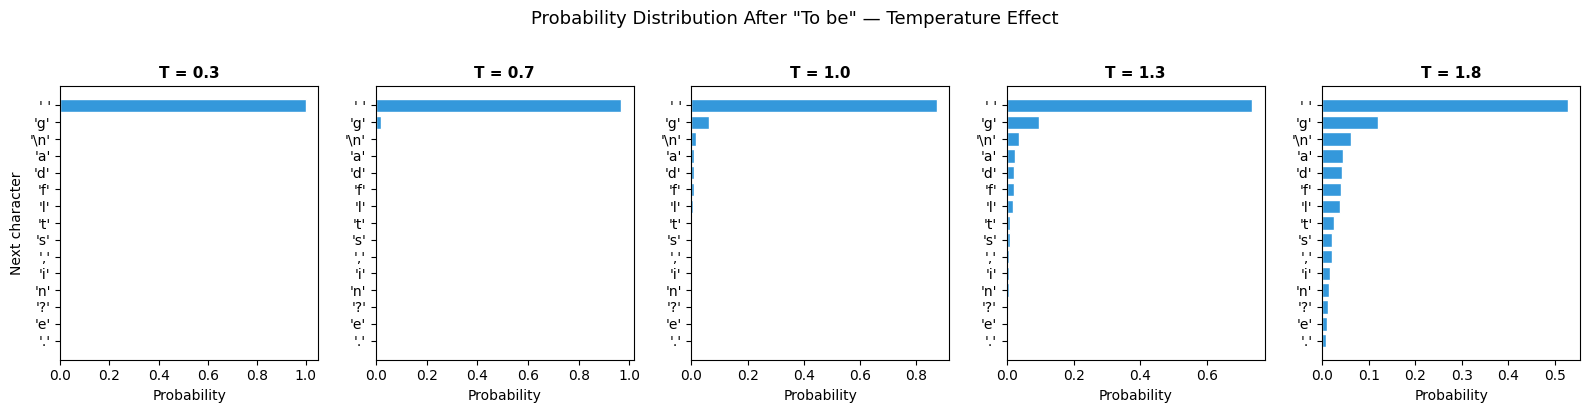

In [12]:
# ── Visualise how temperature reshapes the probability distribution ────────────
# We extract the raw logits from the trained model for the context 'To be'
# and manually apply temperature scaling to show the redistribution.

model.eval()
with torch.no_grad():
    # Encode 'To be' and get logits for the character that follows.
    seed_ids   = torch.tensor([[ch2idx[c] for c in 'To be']], dtype=torch.long).to(device)
    logits, _  = model(seed_ids)
    raw_logits = logits[0, -1, :].cpu().numpy()   # logits for the position after 'e'

# Focus on the top-15 most likely characters at T=1 for clarity.
top_k       = 15
top_indices = np.argsort(raw_logits)[-top_k:][::-1]
top_chars   = [repr(idx2ch[i]) for i in top_indices]

fig, axes = plt.subplots(1, len(temperatures), figsize=(16, 4), sharey=False)

for ax, T in zip(axes, temperatures):
    # Apply temperature scaling and re-normalise manually (equivalent to softmax with T).
    scaled = raw_logits[top_indices] / T
    probs  = np.exp(scaled - scaled.max())   # numerical stability: subtract max first
    probs  = probs / probs.sum()

    ax.barh(top_chars[::-1], probs[::-1], color='#3498DB', edgecolor='white')
    ax.set_title(f'T = {T}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Probability')
    if ax is axes[0]:
        ax.set_ylabel('Next character')

plt.suptitle('Probability Distribution After "To be" — Temperature Effect',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 12. Interactive Generation — Try Your Own Seed

**What this cell does:**  
Provides a simple "playground" cell.
Change `MY_SEED`, `MY_LENGTH`, and `MY_TEMP`, then re-run.

**Tips:**
- Use character names from Shakespeare (`HAMLET:`, `OPHELIA:`, `KING LEAR:`).
- Try `MY_TEMP = 0.5` for clean output; `MY_TEMP = 1.2` for surprising text.
- The seed can be multiple lines — the model will continue from wherever you left off.

In [13]:
# ── Modify these three variables and re-run the cell ──────────────────────────
MY_SEED   = 'HAMLET:\nTo be, or not to be'
MY_LENGTH = 500
MY_TEMP   = 0.8
# ─────────────────────────────────────────────────────────────────────────────

output = generate(model, MY_SEED, length=MY_LENGTH, temperature=MY_TEMP)
print(output)

HAMLET:
To be, or not to bed thou wilt be good up,
As the rages are all as of you.

LARTIUS:
O, I had rather be a country were store those--
Thine is something in himself. I was
have held his ears and fearne to me, and this present
May shame again.

CORIOLANUS:
I would you make it being cannot reservation
To him had pack'd as not a table friends, if
I have ever would be much come to the :omen,
Where you did request your voices: no more!
As for my country I am hear.

LARTIUS:
The theme of undertake is deliver'd?
We are not


---
## 13. What Has the Model Learned?

**What this cell does:**  
Probes four specific structural patterns that the model should have internalised
purely from character-level prediction — no explicit supervision on any of these.

| Probe | What we are testing |
|-------|--------------------|
| `'KING: '` | Does the model produce valid dialogue after a character name? |
| `'Enter '` | Does the model produce a valid stage direction (character name)? |
| `'OPHELIA:\n'` | Does the model understand the name + newline = dialogue format? |
| `'  Shall I compare'` | Does the model continue with verse-like rhythm and rhyme? |

> These structures were never explicitly labelled — the model discovered them
> as the most efficient patterns for predicting the next character.

In [14]:
probes = [
    ('Dialogue after character name',   'KING: ',            0.6),
    ('Stage direction continuation',    'Enter ',            0.6),
    ('Dialogue format (name + newline)','OPHELIA:\n',        0.7),
    ('Verse / iambic rhythm',           '  Shall I compare', 0.7),
]

for label, seed, T in probes:
    out = generate(model, seed, length=100, temperature=T)
    print(f'[ {label} ]')
    print(out)
    print()

[ Dialogue after character name ]
KING: are you stand to the king?
That I may see them not? Come, we know you well.

MENENIUS:
Say, you know

[ Stage direction continuation ]
Enter hath said to give good that our general is cut i'
the middle and grows by pale, and the voluces of t

[ Dialogue format (name + newline) ]
OPHELIA:
SICINIUS:
You have bled together, you shall general.

Second Murderer:
When he wakes! why, fool, he 

[ Verse / iambic rhythm ]
  Shall I comparet to her friends;
You shall enough too?

BRUTUS:
Call't not a proper harm, in all this world
To see 



---
## 14. Compare RNN vs GRU vs LSTM — Quick Run

**What this cell does:**  
Trains three models — plain RNN, GRU, and LSTM — from scratch for a small number of
epochs so we can compare their learning speed and generated text quality side by side.

**Expected results:**
- **Vanilla RNN** converges slowest; struggles with long-range patterns due to vanishing gradients.
- **GRU** typically matches LSTM quality with ~25 % fewer parameters (no cell state).
- **LSTM** usually achieves the lowest perplexity given enough training time.

> `QUICK_EPOCHS = 5` keeps the comparison fast. Increase to 15–20 for a fairer comparison.

In [15]:
QUICK_EPOCHS = 5   # keep short for the session; increase for a fairer comparison


def quick_train(rnn_type: str, epochs: int = QUICK_EPOCHS):
    """Train a fresh CharRNN model of a given type and return it with its loss history.

    Builds the model from scratch (random weights), runs the training loop for the
    given number of epochs, and prints per-epoch progress.  Uses the same
    hyperparameters and dataset as the main training cell so results are comparable.

    Args:
        rnn_type (str): Recurrent cell type — one of 'RNN', 'GRU', or 'LSTM'.
        epochs   (int): Number of training epochs.

    Returns:
        Tuple[CharRNN, List[float]]:
            - Trained model moved to the global `device`.
            - List of average cross-entropy loss values, one per epoch.
    """
    # Fresh model — weights reinitialised from scratch for a fair comparison.
    m    = CharRNN(VOCAB, 64, 256, 2, 0.3, rnn_type).to(device)
    opt  = optim.Adam(m.parameters(), lr=3e-3)
    crit = nn.CrossEntropyLoss()
    losses = []

    for ep in range(1, epochs + 1):
        m.train()
        ep_loss = 0.0

        for xb, yb in dataloader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits, _ = m(xb)
            loss = crit(logits.reshape(-1, VOCAB), yb.reshape(-1))
            loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0)   # prevent gradient explosion
            opt.step()
            ep_loss += loss.item()

        avg = ep_loss / len(dataloader)
        losses.append(avg)
        print(f'  {rnn_type:<5s} epoch {ep}/{epochs}  loss={avg:.4f}  perplexity={math.exp(avg):.1f}')

    return m, losses


# Train all three architectures sequentially.
comp_results = {}
for rtype in ['RNN', 'GRU', 'LSTM']:
    print(f'\nTraining {rtype} ...')
    m, ls = quick_train(rtype)
    comp_results[rtype] = {'model': m, 'losses': ls}


Training RNN ...
  RNN   epoch 1/5  loss=1.7535  perplexity=5.8
  RNN   epoch 2/5  loss=1.6046  perplexity=5.0
  RNN   epoch 3/5  loss=1.5876  perplexity=4.9
  RNN   epoch 4/5  loss=1.5848  perplexity=4.9
  RNN   epoch 5/5  loss=1.5925  perplexity=4.9

Training GRU ...
  GRU   epoch 1/5  loss=1.5091  perplexity=4.5
  GRU   epoch 2/5  loss=1.3209  perplexity=3.7
  GRU   epoch 3/5  loss=1.3031  perplexity=3.7
  GRU   epoch 4/5  loss=1.3073  perplexity=3.7
  GRU   epoch 5/5  loss=1.3352  perplexity=3.8

Training LSTM ...
  LSTM  epoch 1/5  loss=1.4884  perplexity=4.4
  LSTM  epoch 2/5  loss=1.1665  perplexity=3.2
  LSTM  epoch 3/5  loss=1.0779  perplexity=2.9
  LSTM  epoch 4/5  loss=1.0236  perplexity=2.8
  LSTM  epoch 5/5  loss=0.9838  perplexity=2.7


---
### 14a. Visualise the Comparison

**What this cell does:**  
Side-by-side loss and perplexity curves for RNN / GRU / LSTM, plus a
summary table of final perplexity and parameter count.

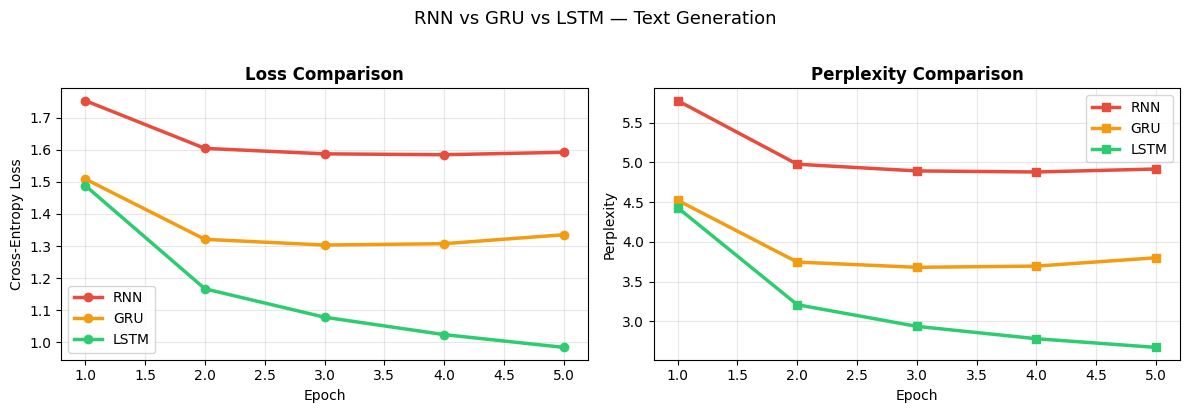


Model  |  Final Perplexity |   Parameters
------------------------------------------
RNN    |               4.9 |      233,918
GRU    |               3.8 |      661,950
LSTM   |               2.7 |      875,966


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = {'RNN': '#E74C3C', 'GRU': '#F39C12', 'LSTM': '#2ECC71'}

for name, res in comp_results.items():
    ep   = range(1, QUICK_EPOCHS + 1)
    perp = [math.exp(l) for l in res['losses']]
    axes[0].plot(ep, res['losses'], label=name, color=colors[name], linewidth=2.5, marker='o')
    axes[1].plot(ep, perp,          label=name, color=colors[name], linewidth=2.5, marker='s')

for ax, title, ylabel in zip(
    axes,
    ['Loss Comparison', 'Perplexity Comparison'],
    ['Cross-Entropy Loss', 'Perplexity']
):
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('RNN vs GRU vs LSTM — Text Generation', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Summary table
print(f'\n{"Model":<6} | {"Final Perplexity":>17} | {"Parameters":>12}')
print('-' * 42)
for name, res in comp_results.items():
    p      = math.exp(res['losses'][-1])
    params = sum(x.numel() for x in res['model'].parameters())
    print(f'{name:<6} | {p:>17.1f} | {params:>12,}')

---
### 14b. Compare Generated Text Quality

**What this cell does:**  
Feeds the same seed to all three trained models and prints the generated text
so you can directly compare the linguistic quality of each architecture.

In [17]:
COMP_SEED = 'KING:\n'
COMP_TEMP = 0.8

print('=' * 60)
print(f'  Seed: {repr(COMP_SEED)}  Temperature: {COMP_TEMP}')
print(f'  (All models trained for {QUICK_EPOCHS} epochs — increase for fairer comparison)')
print('=' * 60)

for name, res in comp_results.items():
    out = generate(res['model'], COMP_SEED, length=150, temperature=COMP_TEMP)
    print(f'\n── {name} ──────────────────────────────────')
    print(out)

  Seed: 'KING:\n'  Temperature: 0.8
  (All models trained for 5 epochs — increase for fairer comparison)

── RNN ──────────────────────────────────
KING:
CORIOLANUS:
Beeaken hear me, never cannot quich
To see to and all,
And such the some show that shork o' the in in the dangereds.

CORIOLANUS:
For he r

── GRU ──────────────────────────────────
KING:
AUFIDIUS:
See to hear you be along.

AeNIUS:
We have made gueed than the will pluck
A laganes of some hand can our prestrains!
Thou hast all the store

── LSTM ──────────────────────────────────
KING:
MENENIUS:
What dost he hath.

GLOUCESTER:
Fairer than than a letter from him.

MARCIUS:
I'll buy him of your tent;
And that it was for me?

MARCIUS:
W


---
## 15. Key Takeaways

| Concept | What we saw |
|---------|-------------|
| **Character-level LM** | The model only ever predicts the next character — all higher-level structure (words, punctuation, dialogue) emerges from this single objective |
| **Perplexity** | `exp(loss)` — how many characters the model is equally confused between; a random model scores ≈ vocab_size |
| **Hidden state** | The RNN's memory — carries context forward across the entire sequence without explicit storage |
| **Teacher forcing** | During training we supply the true previous character; at inference we use our own predictions — this gap is called *exposure bias* |
| **Temperature sampling** | Dividing logits by `T` before softmax controls the sharpness of the distribution; it is the simplest form of *controlled generation* |
| **LSTM > RNN** | Especially visible on long sequences — the cell state acts as a direct gradient highway, bypassing the vanishing gradient problem |
| **GRU vs LSTM** | GRU achieves similar quality with fewer parameters; preferred when compute is limited |

---
## 16. Exercises

1. **Change the corpus** — replace `shakespeare.txt` with Python source code, song lyrics, or a Wikipedia article. What does the model learn to mimic?
2. **Bigger model** — set `hidden_dim=512`, `num_layers=3`. Does the final perplexity improve?
3. **Longer context** — increase `SEQ_LEN` from 100 to 200. How does training time change? Does generated text show longer coherent passages?
4. **Top-k sampling** — modify `generate()` to zero out all probabilities except the top-k before sampling. Compare the output with pure temperature sampling.
5. **Bidirectional warm-up** — use a `bidirectional=True` LSTM to encode the seed, then feed the final hidden state to a unidirectional decoder.
6. **Visualise hidden states** — collect the hidden state vector at each position as the model reads a sentence; apply PCA and plot — what does the model track?